In [1]:
import sys
sys.path.append("../src")

In [2]:
from data_loader import load_data

df = load_data("../data/raw/complaints.csv")

print(df.shape)
df.head()

c:\Users\habtamu.amsalu\Downloads\rag-complaint-chatbot-\notebooks\../src\data_loader.py:4: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


(9609797, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [3]:
from eda import (plot_product_distribution,
                 narrative_length_analysis,
                 narrative_presence_analysis)

In [4]:
df["Product"].unique()

<StringArray>
[                         'Credit reporting or other personal consumer reports',
                                                              'Debt collection',
                                                                  'Credit card',
                                                  'Checking or savings account',
                           'Money transfer, virtual currency, or money service',
                                                        'Vehicle loan or lease',
                                                    'Debt or credit management',
                                                                     'Mortgage',
                      'Payday loan, title loan, personal loan, or advance loan',
                                                                 'Prepaid card',
                                                                 'Student loan',
                                                             'Credit reporting',
 'Credit repor

c:\Users\habtamu.amsalu\Downloads\rag-complaint-chatbot-\notebooks\../src\eda.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


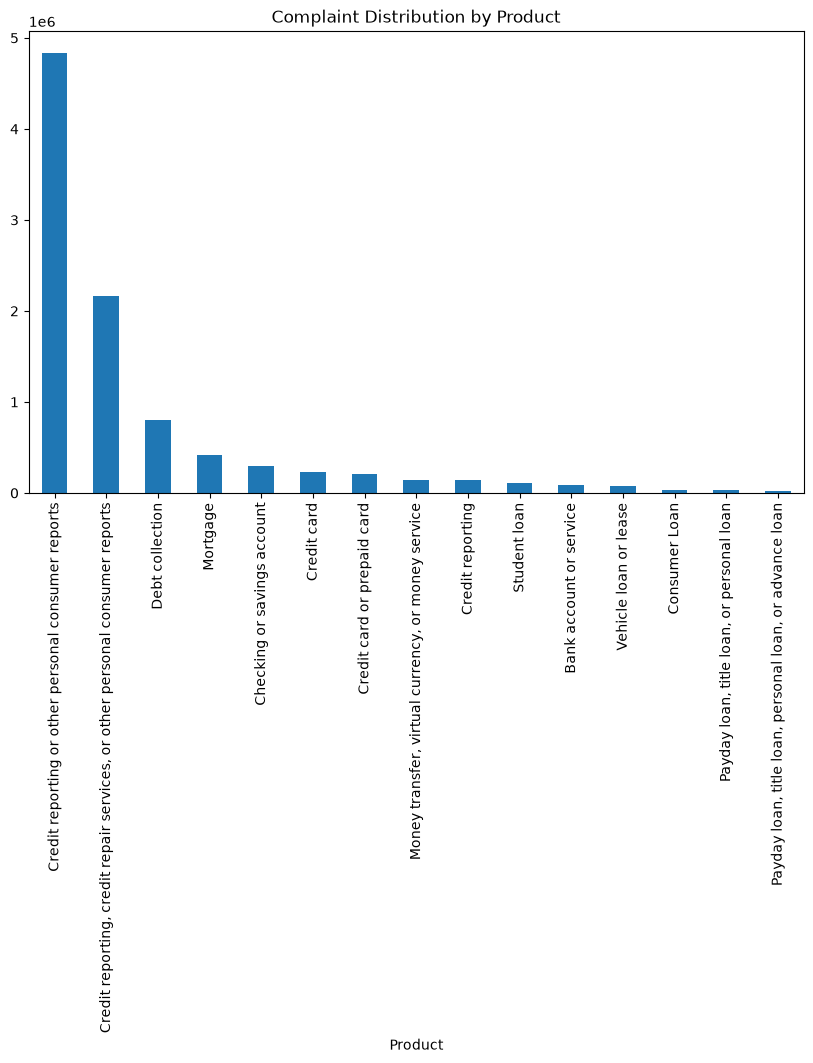

In [5]:
plot_product_distribution(df)

In [ ]:
df = narrative_length_analysis(df)

In [ ]:
narrative_presence_analysis(df)

With Narrative: 2980756
Without Narrative: 6629041


In [ ]:
target_products = [
      "Credit card",
      "Personal loan",
      "Savings account",
      "Money transfer"
]

In [ ]:
from preprocessing import filter_products

filtered_df = filter_products(df, target_products)

In [ ]:
from preprocessing import remove_empty_narratives

filtered_df = remove_empty_narratives(filtered_df)

In [ ]:
from preprocessing import clean_text

filtered_df["cleaned_narrative"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(clean_text)
)

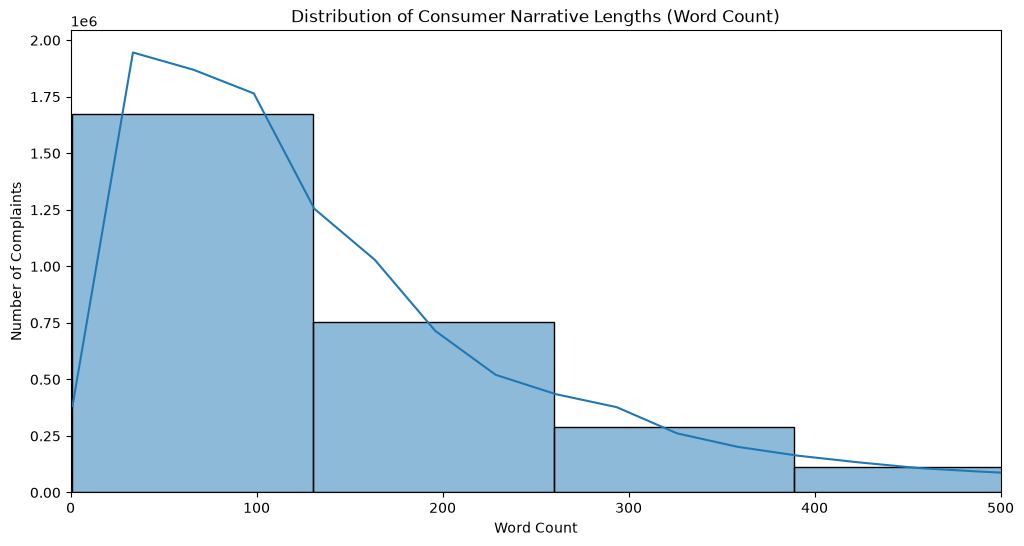

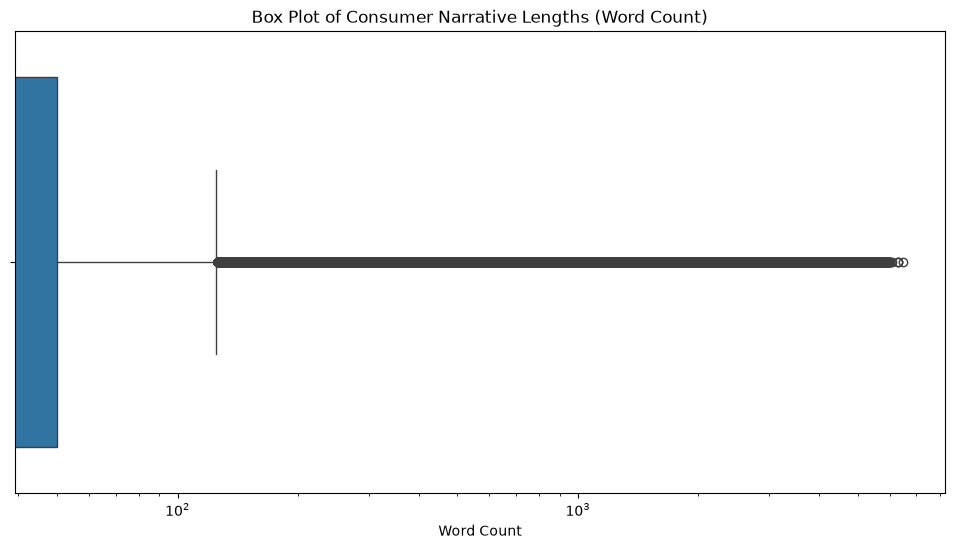

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' with 'word_count' is available from previous steps
# If not, re-run narrative_length_analysis(df) earlier.

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'][df['word_count'] > 0], bins=50, kde=True)
plt.title('Distribution of Consumer Narrative Lengths (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Number of Complaints')
plt.xlim(0, 500) # Limit x-axis for better visualization of common lengths
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['word_count'])
plt.title('Box Plot of Consumer Narrative Lengths (Word Count)')
plt.xlabel('Word Count')
plt.xscale('log') # Use log scale for better visualization of outliers
plt.show()

In [ ]:
print("===== BEFORE CLEANING =====")

df[['Consumer complaint narrative']].head()

===== BEFORE CLEANING =====


,Consumer complaint narrative
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [ ]:
filtered_df["cleaned_narrative"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(clean_text)
)

In [ ]:
print("===== AFTER CLEANING =====")

filtered_df[['cleaned_narrative']].head()

===== AFTER CLEANING =====


,cleaned_narrative
12237,a card was opened under my name by a fraudster...
13280,i have a secured credit card with citibank whi...
13506,i have a citi rewards cards the credit balance...
13955,the following charges on my citi credit card a...
14249,although the account had been deemed closed i ...


In [ ]:
comparison = filtered_df[
    ['Consumer complaint narrative']
].copy()

comparison['cleaned_narrative'] = (
    filtered_df['Consumer complaint narrative']
    .apply(clean_text)
)

comparison.head()

,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...
13280,"Dear CFPB, I have a secured credit card with c...",i have a secured credit card with citibank whi...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,the following charges on my citi credit card a...
14249,"Although the account had been deemed closed, I...",although the account had been deemed closed i ...


In [ ]:
filtered_df.to_csv(
    "../data/filtered_complaints.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [ ]:
from data_loader import load_data

df = load_data("../data/filtered_complaints.csv")

print(df.shape)
df.head()

(80667, 20)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,cleaned_narrative
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,91,a card was opened under my name by a fraudster...
1,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,156,i have a secured credit card with citibank whi...
2,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,233,i have a citi rewards cards the credit balance...
3,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,454,the following charges on my citi credit card a...
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,"Although the account had been deemed closed, I...",Company believes it acted appropriately as aut...,Atlanticus Services Corporation,NY,11212,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13965746,170,although the account had been deemed closed i ...


In [ ]:
print(df["Product"].value_counts())

Product
Credit card    80667
Name: count, dtype: int64
